In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definición de los métodos numéricos ---
def euler_method(C0, k, t, dt):
    C = np.zeros(len(t))
    C[0] = C0
    for i in range(len(t)-1):
        dCdt = -k * C[i]
        C[i+1] = C[i] + dt * dCdt
    return C

def rk4_method(C0, k, t, dt):
    C = np.zeros(len(t))
    C[0] = C0
    for i in range(len(t)-1):
        k1 = -k * C[i]
        k2 = -k * (C[i] + dt * k1 / 2)
        k3 = -k * (C[i] + dt * k2 / 2)
        k4 = -k * (C[i] + dt * k3)
        C[i+1] = C[i] + dt * (k1 + 2*k2 + 2*k3 + k4) / 6
    return C

def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))


In [2]:
# --- 2. Parámetros del problema ---
k = 0.5
C0 = 1.0
t0 = 0
tf = 10
dt_values = [2.0, 1.0, 0.1] 

Resultados de Error Cuadrático Medio (RMSE):
---------------------------------------------
Paso temporal (dt) = 2.0
  RMSE Euler: 0.161509
  RMSE RK4:   3.872131e-03

Paso temporal (dt) = 1.0
  RMSE Euler: 0.063786
  RMSE RK4:   1.684363e-04

Paso temporal (dt) = 0.1
  RMSE Euler: 0.005639
  RMSE RK4:   1.206567e-08



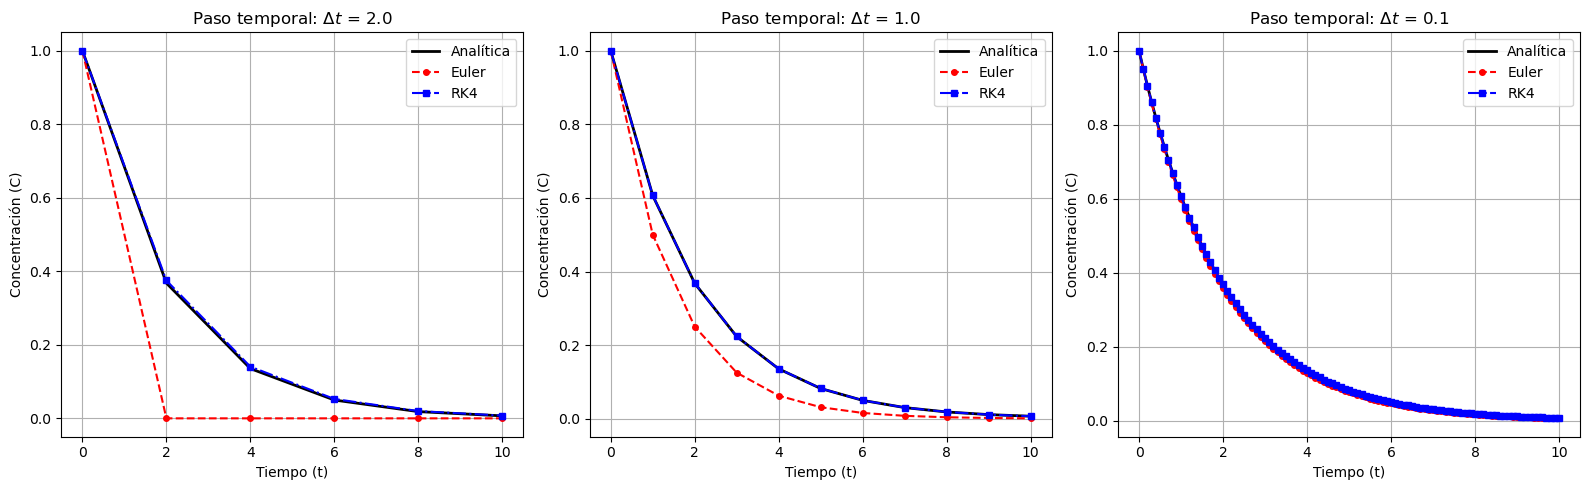

In [3]:
# --- 3. Ejecución de simulaciones y visualización ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

print("Resultados de Error Cuadrático Medio (RMSE):\n" + "-"*45)

for idx, dt in enumerate(dt_values):
    t = np.arange(t0, tf + dt, dt)
    C_exact = C0 * np.exp(-k * t)
    
    C_euler = euler_method(C0, k, t, dt)
    C_rk4 = rk4_method(C0, k, t, dt)
    
    rmse_euler = calc_rmse(C_exact, C_euler)
    rmse_rk4 = calc_rmse(C_exact, C_rk4)
    
    print(f"Paso temporal (dt) = {dt}")
    print(f"  RMSE Euler: {rmse_euler:.6f}")
    print(f"  RMSE RK4:   {rmse_rk4:.6e}\n")
    
    ax = axes[idx]
    ax.plot(t, C_exact, 'k-', linewidth=2, label='Analítica')
    ax.plot(t, C_euler, 'r--', marker='o', markersize=4, label='Euler')
    ax.plot(t, C_rk4, 'b-.', marker='s', markersize=4, label='RK4')
    
    ax.set_title(f'Paso temporal: $\Delta t$ = {dt}')
    ax.set_xlabel('Tiempo (t)')
    ax.set_ylabel('Concentración (C)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Deltat = 2.0: Euler = 0.161509, RK4 = 0.003872
Deltat = 1.0: Euler = 0.063786, RK4 = 0.000168
Deltat = 0.1: Euler = 0.005639, RK4 = 0.000000012
 
a) ¿Cómo cambia el error numérico cuando el paso temporal Δt aumenta o disminuye?

Si Δt disminuye (pasos más pequeños): El error numérico se hace mínimo. Como la computadora hace cálculos más seguido, logra "dibujar" casi a la perfección la curva real sin desviarse.

Si Δt aumenta (pasos más grandes): El error se dispara. Al dejar pasar demasiado tiempo entre cada cálculo, el método asume cosas que no son, se "salta" información importante y el resultado final se aleja totalmente de la realidad.

b) ¿Cuál de los dos métodos muestra mayor estabilidad y precisión?

El método RK4 (Runge-Kutta de 4to orden) es el claro ganador en ambas.

Precisión: RK4 es mucho más exacto porque hace varios cálculos de prueba internamente antes de dar el siguiente paso. Euler es muy básico y acumula errores rápidamente.

Estabilidad: Se nota sobre todo con el paso grande (Δt = 2). Mientras que Euler colapsa por completo y arroja un resultado sin sentido (la concentración cae a cero de golpe), RK4 aguanta ese paso grande sin "romperse" y sigue dibujando la curva correctamente.

c) ¿Qué implicaciones tiene el tamaño del paso temporal en modelos para sistemas geoquímicos?
Básicamente, se resume en dos problemas prácticos al programar el modelo:

Evitar resultados "mágicos" o imposibles: En la geoquímica hay reacciones que pasan en segundos y otras que toman años. Si le das a tu programa un paso (Δt) muy grande, se vuelve loco y puede arrojar absurdos físicos, como decirte que hay una "cantidad negativa" de un mineral.

El dilema del tiempo de procesamiento: Si eliges un paso súper pequeño para ser 100% exacto, la computadora tendrá que hacer millones de cálculos y tardará días en terminar la simulación. La clave es usar métodos inteligentes como RK4, que te permiten usar pasos medianos para ahorrar tiempo de cómputo sin que el modelo químico pierda la exactitud.